In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate

In [2]:
DIMENSION = '1K'

In [3]:
DATASET = f'../../datasets/paysim/{DIMENSION}/rawLog.csv'

In [4]:
import csv

# Open the CSV file
with open(DATASET, mode='r', newline='') as infile:
    reader = csv.DictReader(infile)
    rows = list(reader)

In [5]:
# Initialize balances dictionary
balances = {}

# Modify the rows
for row in rows:
    try:
        orig = row['nameOrig']
        dest = row['nameDest']
        amount = float(row['amount'])
        action = row['action']

        # Use the last known balance or fallback to the CSV value
        old_balance_orig = balances.get(orig, float(row['oldBalanceOrig']))
        old_balance_dest = balances.get(dest, float(row['oldBalanceDest']))

        if action == 'CASH_IN':
            # dest gains money
            new_balance_dest = old_balance_dest - amount
            balances[dest] = new_balance_dest  # Update the live balance
            row['newBalanceDest'] = new_balance_dest
            row['oldBalanceDest'] = old_balance_dest  # <-- also important to update oldBalanceDest!
        
        elif action == 'CASH_OUT' or action == 'DEBIT':
            # orig loses money
            new_balance_dest = old_balance_dest + amount
            balances[dest] = new_balance_dest
            row['newBalanceDest'] = new_balance_dest
            row['oldBalanceDest'] = old_balance_dest  # <-- also important to update oldBalanceOrig!

        # Optionally handle other actions like TRANSFER, PAYMENT, etc.

    except ValueError:
        # Handle invalid values if needed
        row['newBalanceDest'] = ''
        row['newBalanceOrig'] = ''


In [6]:
# Write back to a new CSV file (or overwrite the original)
NEW_DATASET = F"paysim{DIMENSION}.csv"
with open(NEW_DATASET, mode='w', newline='') as outfile:
    writer = csv.DictWriter(outfile, fieldnames=reader.fieldnames)
    writer.writeheader()
    for row in rows:
        writer.writerow(row)

In [7]:
DATASET = f'../../datasets/paysim/{DIMENSION}/rawLog.csv'

df = pd.read_csv(NEW_DATASET)
# df = df.iloc[:500000]
df

,step,action,amount,nameOrig,oldBalanceOrig,newBalanceOrig,nameDest,oldBalanceDest,newBalanceDest,isFraud,isFlaggedFraud,isUnauthorizedOverdraft
0,0,TRANSFER,10.00,C0846262187,35.34,25.34,C0717868729,40.69,50.69,0,0,0
1,1,CASH_IN,28609.06,C1214850814,548859.60,577468.66,M2919619279,0.00,-28609.06,0,0,0
2,1,CASH_IN,329530.87,C6211100334,229397.85,558928.72,M4047861076,0.00,-329530.87,0,0,0
3,1,CASH_IN,89146.98,C6211100334,558928.72,648075.70,M5841240249,0.00,-89146.98,0,0,0
4,1,CASH_IN,149891.62,C9172828351,37097.25,186988.87,M7837689440,0.00,-149891.62,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
103879,361,PAYMENT,8137.89,C5206479787,4036108.44,4027970.55,M4921136203,639386.24,647524.13,0,0,0
103880,361,PAYMENT,17475.98,C7969065034,4505669.56,4488193.58,M0555189920,683555.45,701031.44,0,0,0
103881,362,CASH_IN,166040.83,C4027681161,4217223.13,4383263.96,M4538780990,-16160225.86,-16326266.69,0,0,0
103882,362,TRANSFER,50.00,C9349914008,3484253.76,3484203.76,C0717868729,3193712.68,3193762.68,0,0,0


In [8]:
prefixes1 = df['nameOrig'].str[0].unique()
prefixes2 = df['nameDest'].str[0].unique()

print(prefixes1, prefixes2)

df['action'].unique()

['C'] ['C' 'M' 'B']


array(['TRANSFER', 'CASH_IN', 'DEBIT', 'PAYMENT', 'CASH_OUT'],
      dtype=object)

In [15]:
df['isFraud'].unique()

array([0, 1])

In [9]:
balances = {}
fraud = 0

for _, row in df.iterrows():
    is_fraud = row['isFraud']
    orig = row['nameOrig']
    dest = row['nameDest']
    oldorig = row['oldBalanceOrig']
    olddest = row['oldBalanceDest']
    neworig = row['newBalanceOrig']
    newdest = row['newBalanceDest']

    # Track origin account
    if row['nameOrig'] not in balances:
        balances[row['nameOrig']] = {}
    balances[row['nameOrig']][row['step']] = row['newBalanceOrig']

    if orig == 'M7146327871':
        print(f"step : {row['step']}")
        print(f"amount: {row['amount']}")
        print(f"old orig: {oldorig}")
        print(f"new orig: {neworig}")
    if dest == 'M7146327871':
        print(f"step : {row['step']}")
        print(f"amount: {row['amount']}")
        print(f"old dest: {olddest}")
        print(f"new dest: {newdest}")

    # Track destination account
    if row['nameDest'] not in balances:
        balances[row['nameDest']] = {}
    balances[row['nameDest']][row['step']] = row['newBalanceDest']

    if is_fraud:
        fraud += 1

In [10]:
print(f"Total fraudolent transactions: {fraud} out of {len(df)} transactions")
fraud_perc = fraud / len(df)
print(f"Anomaly percentage: {round(fraud_perc * 100, 2)}")

Total fraudolent transactions: 128 out of 103884 transactions
Anomaly percentage: 0.12


In [11]:
print(f"Number of users: {len(balances)}")

Number of users: 1026


In [12]:
# Create DataFrame
balance_df = pd.DataFrame.from_dict(balances, orient='index').T

# Identify the full range of steps (days)
full_range = range(balance_df.index.min(), balance_df.index.max() + 1)

# Reindex to include all steps, then forward fill
balance_df = balance_df.reindex(full_range).fillna(method='ffill').fillna(method='bfill')

/var/folders/s6/4jprwbqj4012tkll2ww6r5hr0000gq/T/ipykernel_21864/707783276.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  balance_df = balance_df.reindex(full_range).fillna(method='ffill').fillna(method='bfill')


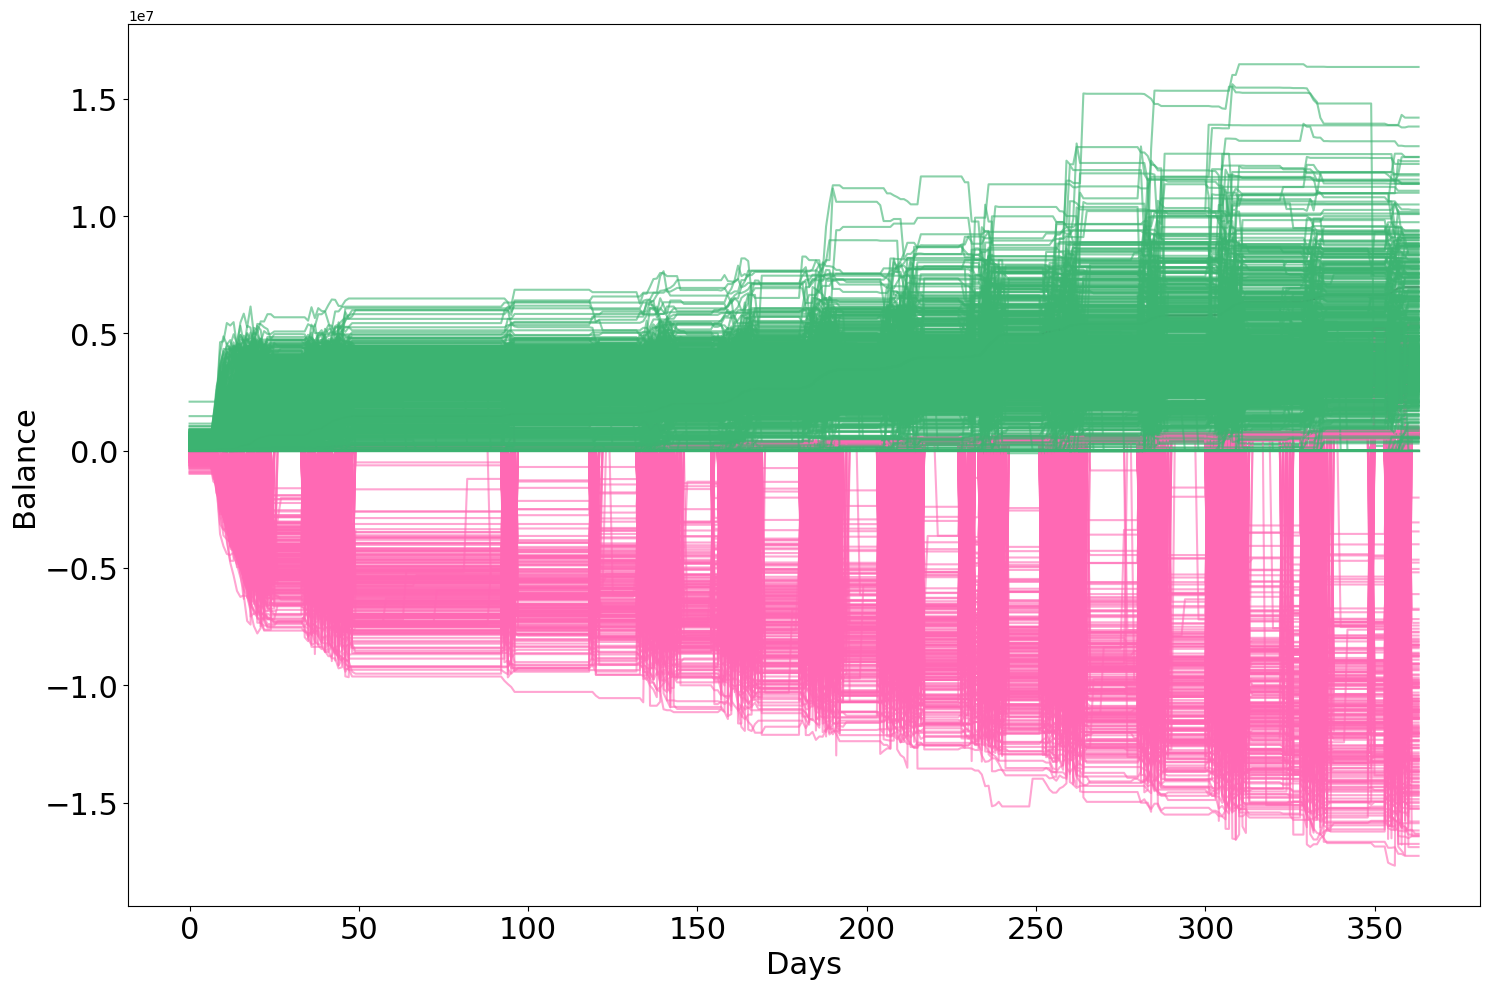

In [14]:
# Plot the balance evolution for all users (columns) as separate lines
# plt.figure(figsize=(15,10), dpi= 300)
plt.figure(figsize=(15,10))

# Plot each column (account balance) as a line
for user in balance_df.columns:
    if user.startswith('C'):
        color = 'mediumseagreen'
    elif user.startswith('B'):
        color = 'black'
    else:
        color = 'hotpink'
    plt.plot(balance_df.index, balance_df[user], color=color, label=f"User {user}", alpha=0.6)

# Add title and labels
plt.xlabel("Days", fontsize=22)
plt.ylabel("Balance", fontsize=22)

# Rotate x-axis labels for better visibility
plt.tick_params(axis='x', labelsize=22)
plt.tick_params(axis='y', labelsize=22)

# Display the plot
plt.tight_layout()
plt.show()

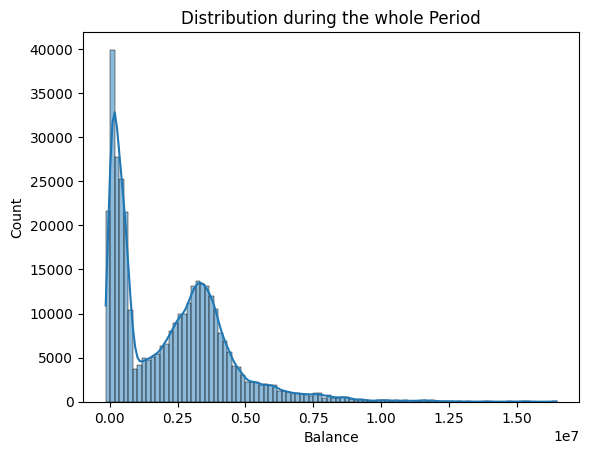

In [14]:
values_df = balance_df.values.flatten()
# Plot distribution for all the days (aggregated over users and days)
sns.histplot(values_df, bins=100, kde=True)
plt.title("Distribution during the whole Period")
plt.xlabel("Balance")
plt.show()

In [15]:
balance_df.T

,0,1,2,3,4,5,6,7,8,9,...,354,355,356,357,358,359,360,361,362,363
C0846262187,25.34,25.34,25.34,25.34,25.34,25.34,25.34,225923.62,575614.67,1131265.25,...,4104159.53,3912787.61,3888693.62,3944852.86,4053379.37,4053379.37,4053329.37,4053329.37,4053329.37,4053329.37
C0717868729,50.69,50.69,50.69,50.69,50.69,50.69,50.69,250.69,250.69,250.69,...,2852724.92,3105669.15,3105669.15,3105679.15,3193652.68,3193652.68,3193702.68,3193712.68,3193762.68,3193782.68
M2919619279,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,666175.11,678327.61,708436.96,708436.96,708436.96,708436.96,708436.96,708436.96,708436.96,708436.96
C6211100334,648075.70,648075.70,648075.70,648075.70,648075.70,648075.70,648075.70,991322.63,2587341.31,3297478.78,...,3663754.20,3472580.02,3527309.32,4088214.80,4270971.85,3979810.66,4047619.33,4047619.33,4047619.33,4047619.33
M4047861076,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,582902.29,582902.29,600285.27,600285.27,606721.79,611790.72,621404.97,621404.97,621404.97,621404.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CC3621028696,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,296673.12,296673.12,296673.12,296673.12,296673.12
CC7441141329,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
CC4277777362,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
CC0857455303,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


# SQUIC

In [16]:
df = balance_df

In [17]:
ROWS = len(df.iloc[0])
ROWS

1026

## Non-Normalization

In [18]:
Y = df.T.to_numpy()  # Transpose to get shape (users, days)
#l = [1e5, 3e5, 5e5, 7e5, 9e5, 11e5, 13e5, 15e5, 17e5, 19e5]

l = [9e-1, 5e-1, 2e-1, 1e-1, 9e-2, 5e-2, 2e-2, 1e-2, 1e-3]

In [19]:
print(np.isnan(Y).sum())  # should be 0 (no NaN)
print(np.linalg.matrix_rank(Y))  # should be full rank (ideally)
print(np.linalg.cond(Y))  # condition number; high = bad

0
257
3.8139533479558775e+20


In [20]:
from SQUIC_functions import *

In [21]:
squic_dict = {}

If non normalized non sparse results

In [22]:
# data_nnz = []
# data_nnzr = []
# data_time = []

# for rho in l:
#     X, _, computation_time = compute_squic(Y, rho)
#     computation_time = round(computation_time, 2)
#     squic_dict[rho] = X
#     print(f"time required: {computation_time} seconds")

#     nonz, nonz_r = count_nnz(squic_dict[rho], ROWS)

#     data_nnz.append(nonz)
#     data_nnzr.append(nonz_r)
#     data_time.append(computation_time)

#     if nonz == ROWS:
#         print(f"For rho = {rho} just element on the diagonal")
#         sparsity_pattern(squic_dict[rho])
#     elif nonz == ROWS * ROWS:
#         print(f"For rho = {rho} big dense matrix")
#         sparsity_pattern(squic_dict[rho])
#         print(f"nnz = {nonz}")
#         print(f"nnz/row = {nonz_r}")
#     else:
#         print(f"For rho = {rho} there are some nnz")
#         sparsity_pattern(squic_dict[rho])
#         print(f"nnz = {nonz}")
#         print(f"nnz/row = {nonz_r}")
#         if is_symmetric(squic_dict[rho]):
#             print(f"✅ Matrix is symmetric per rho {rho}")
#         else:
#             print(f"❌ Matrix is not symmetric per rho {rho}")
        

# data_df = [
#     ["NNZ"] + data_nnz,
#     ["NNZ/Row"] + data_nnzr,
#     ["Time (s)"] + data_time
# ]

## Normalization

In [23]:
Y = df.T.to_numpy()
# normalize the Y input data to achieve unit variance
Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
# normalizes each row so that the std dev of each user's balance over the days becomes 1

# Y_new has shape (Users × Days).
# S will have shape (Users × Users).

# double check if this is correct by 
S = np.cov(Y_new, bias=True) # "bias=true" you force cove to use n samples instead of n-1

/var/folders/s6/4jprwbqj4012tkll2ww6r5hr0000gq/T/ipykernel_15620/3409128255.py:3: RuntimeWarning: divide by zero encountered in divide
  Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation


In [24]:
print("NaNs?", np.isnan(Y_new).any())
print("Infs?", np.isinf(Y_new).any())
print("Max:", np.max(Y_new))
print("Min:", np.min(Y_new))
print("Mean std per row (should be 1):", np.mean(np.std(Y_new, axis=1)))

NaNs? True
Infs? False
Max: nan
Min: nan
Mean std per row (should be 1): nan


In [25]:
stds = np.std(Y, axis=1)
safe_stds = np.clip(stds, 1e-8, None)  # don't allow std < 1e-8
Y_new = np.diag(1 / safe_stds) @ Y

print("NaNs?", np.isnan(Y_new).any())
print("Infs?", np.isinf(Y_new).any())
print("Max:", np.max(Y_new))
print("Min:", np.min(Y_new))
print("Mean std per row (should be 1):", np.mean(np.std(Y_new, axis=1)))

NaNs? False
Infs? False
Max: 9.831992323654356
Min: -0.1367383681081601
Mean std per row (should be 1): 0.9922027290448342


In [26]:
print(np.linalg.cond(Y_new))  # condition number; high = bad

3.1606902635048934e+20


In [37]:
l = [0.998, 0.997, 0.996, 0.995, 0.994, 0.993, 0.992, 0.99, 0.95]

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1026 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=9.13e-03 nnz(S)/p=1.00e+00
* iter=1 time=3.35e-03 obj=5.13e+08 |delta(obj)|/obj=1.00e+00 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=2 
* iter=2 time=3.52e-03 obj=2.57e+08 |delta(obj)|/obj=1.00e+00 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=2 
* iter=3 time=3.69e-03 obj=1.28e+08 |delta(obj)|/o

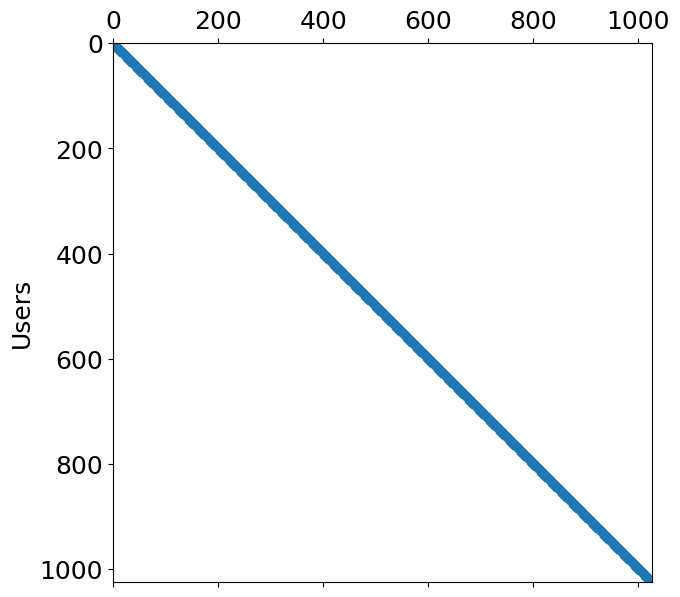

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1026 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e+05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.00e-03 nnz(S)/p=1.00e+00
* iter=1 time=2.58e-03 obj=5.13e+07 |delta(obj)|/obj=1.00e+00 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=2 
* iter=2 time=3.54e-03 obj=2.57e+07 |delta(obj)|/obj=1.00e+00 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=2 
* iter=3 time=4.79e-03 obj=1.28e+07 |delta(obj)|/o

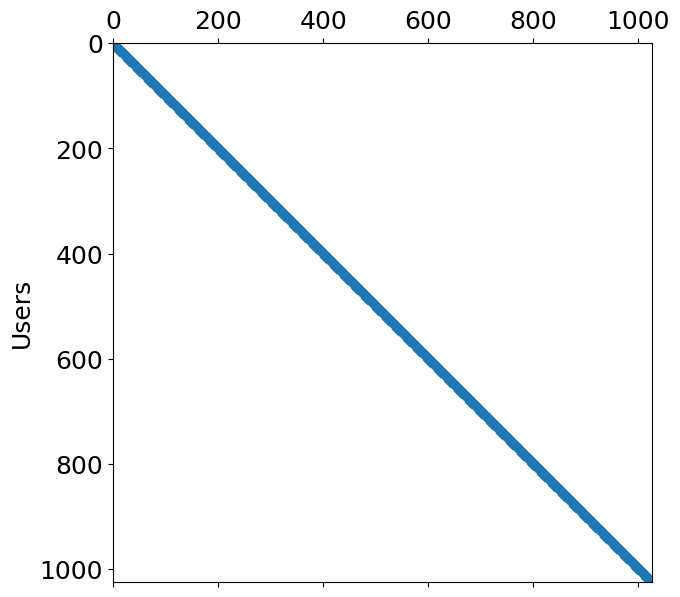

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1026 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e+03 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.22e-03 nnz(S)/p=1.00e+00
* iter=1 time=1.96e-03 obj=5.14e+05 |delta(obj)|/obj=9.98e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=2 
* iter=2 time=2.83e-03 obj=2.58e+05 |delta(obj)|/obj=9.92e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=2 
* iter=3 time=4.02e-03 obj=1.31e+05 |delta(obj)|/o

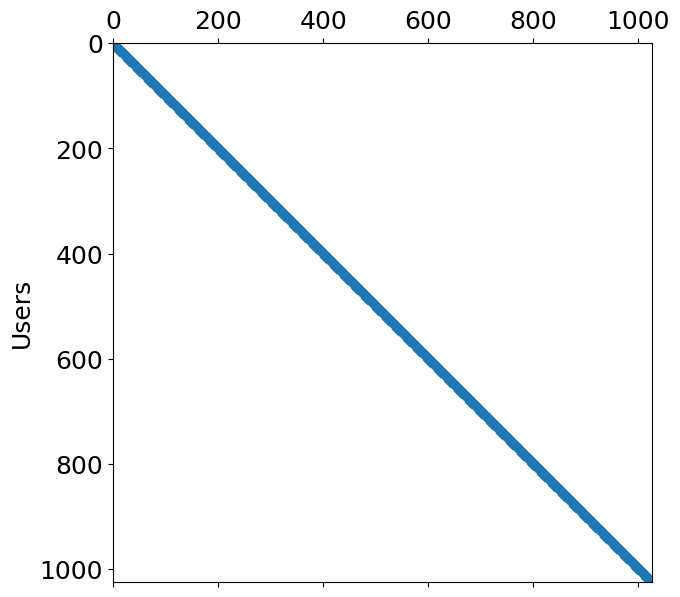

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1026 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e+02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.54e-03 nnz(S)/p=1.00e+00
* iter=1 time=1.84e-03 obj=5.25e+04 |delta(obj)|/obj=9.81e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=2 
* iter=2 time=2.91e-03 obj=2.73e+04 |delta(obj)|/obj=9.22e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=2 
* iter=3 time=4.18e-03 obj=1.51e+04 |delta(obj)|/o

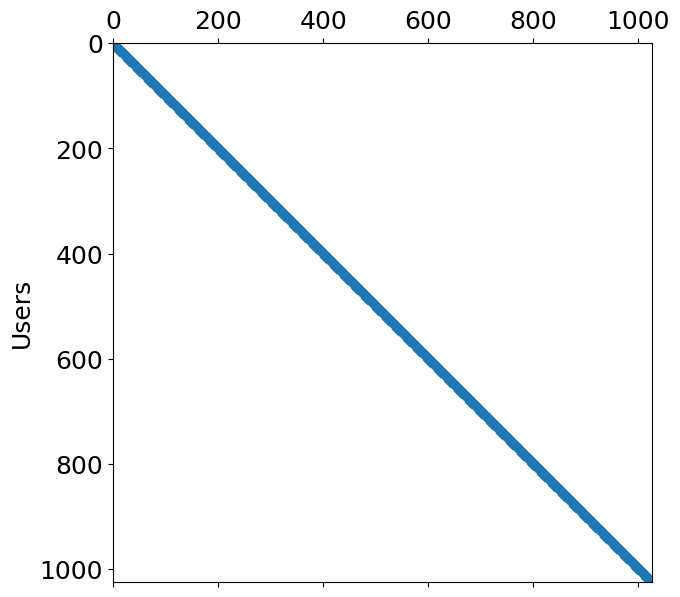

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1026 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e+01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.51e-03 nnz(S)/p=1.00e+00
* iter=1 time=2.05e-03 obj=6.35e+03 |delta(obj)|/obj=8.40e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=2 
* iter=2 time=2.82e-03 obj=4.24e+03 |delta(obj)|/obj=4.97e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=2 
* iter=3 time=1.16e-02 obj=3.54e+03 |delta(obj)|/o

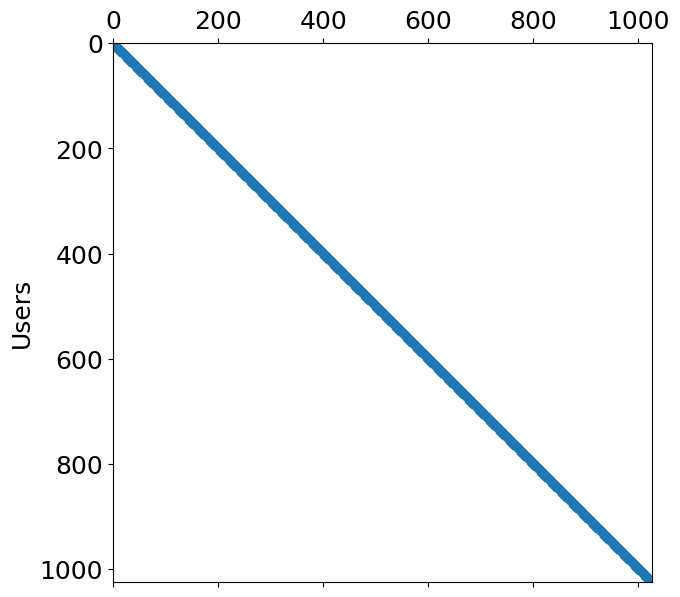

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1026 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e+00 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.44e-03 nnz(S)/p=1.00e+00
* iter=1 time=2.13e-03 obj=1.73e+03 |delta(obj)|/obj=4.12e-01 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=2 
* iter=2 time=3.35e-03 obj=1.73e+03 |delta(obj)|/obj=0.00e+00 nnz(X,L,W)/p=[1.00e+00 5.00e-01 1.00e+00] lns_iter=1 
#SQUIC Finished: time=1.02e-02 nnz(X,W)/p=[1.00e+0

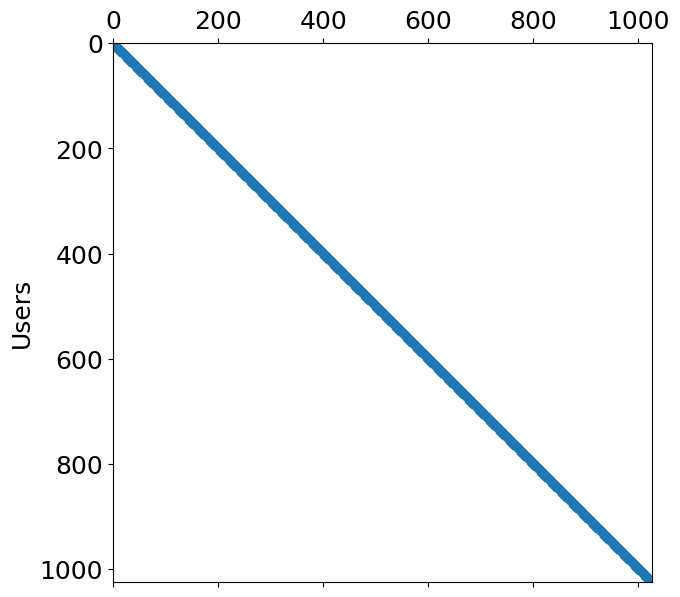

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1026 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.980000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.29e-03 nnz(S)/p=1.12e+00
* iter=1 time=2.32e-03 obj=6.37e+03 |delta(obj)|/obj=8.40e-01 nnz(X,L,W)/p=[1.12e+00 6.62e-01 1.06e+00] lns_iter=1 
* iter=2 time=2.96e-03 obj=5.67e+03 |delta(obj)|/obj=1.23e-01 nnz(X,L,W)/p=[1.12e+00 6.62e-01 1.10e+00] lns_iter=1 
* iter=3 time=3.95e-03 obj=4.98e+03 |delta(obj)|/o

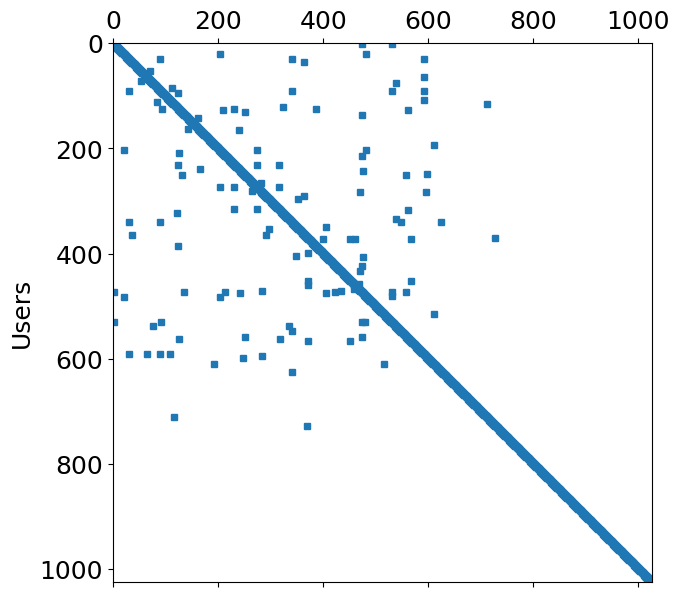

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1026 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.970000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.48e-03 nnz(S)/p=2.11e+00
* iter=1 time=2.45e-03 obj=1.73e+03 |delta(obj)|/obj=4.12e-01 nnz(X,L,W)/p=[2.11e+00 3.62e+00 1.00e+00] lns_iter=2 
* iter=2 time=3.28e-03 obj=1.73e+03 |delta(obj)|/obj=5.72e-07 nnz(X,L,W)/p=[2.11e+00 3.62e+00 1.00e+00] lns_iter=1 
#SQUIC Finished: time=9.59e-03 nnz(X,W)/p=[2.11e+0

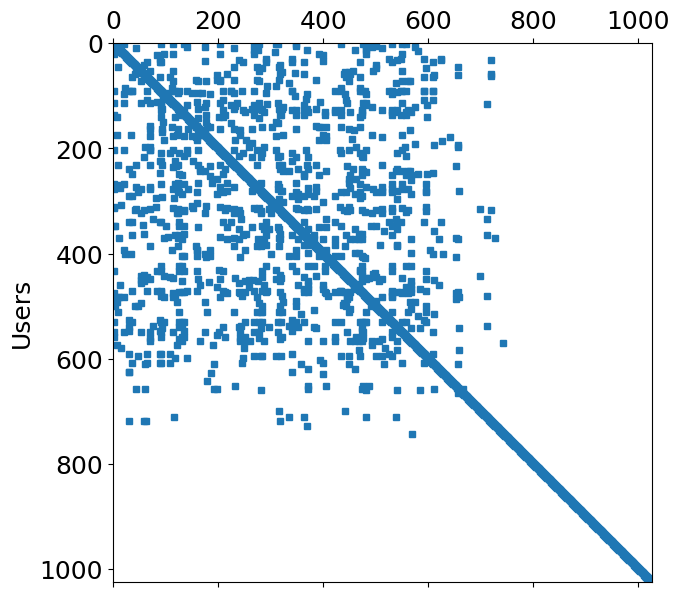

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1026 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.960000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.76e-03 nnz(S)/p=4.93e+00
* iter=1 time=3.09e-03 obj=1.73e+03 |delta(obj)|/obj=4.11e-01 nnz(X,L,W)/p=[4.93e+00 1.08e+01 1.00e+00] lns_iter=2 
* iter=2 time=4.23e-03 obj=1.73e+03 |delta(obj)|/obj=4.18e-07 nnz(X,L,W)/p=[4.93e+00 1.08e+01 1.00e+00] lns_iter=1 
#SQUIC Finished: time=1.14e-02 nnz(X,W)/p=[4.93e+0

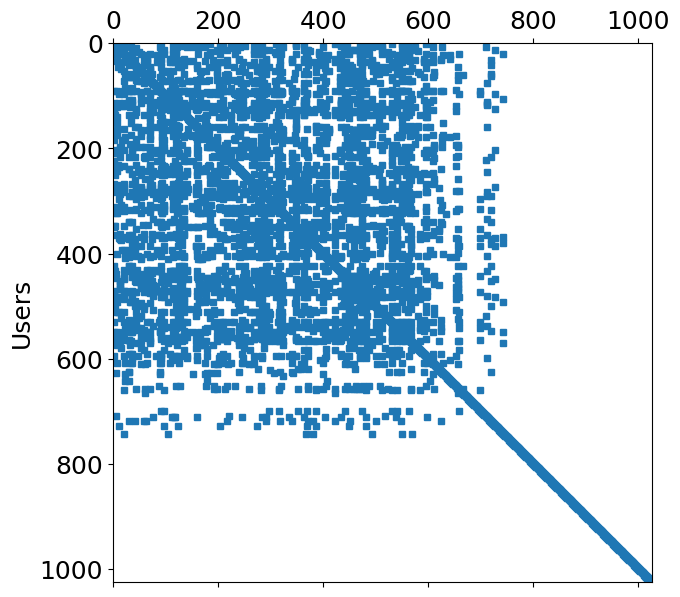

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1026 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.950000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.66e-03 nnz(S)/p=9.49e+00
* iter=1 time=4.90e-03 obj=1.73e+03 |delta(obj)|/obj=4.11e-01 nnz(X,L,W)/p=[9.49e+00 1.85e+01 1.00e+00] lns_iter=2 
* iter=2 time=5.68e-03 obj=1.73e+03 |delta(obj)|/obj=0.00e+00 nnz(X,L,W)/p=[9.49e+00 1.85e+01 1.28e+00] lns_iter=1 
#SQUIC Finished: time=1.63e-02 nnz(X,W)/p=[9.49e+0

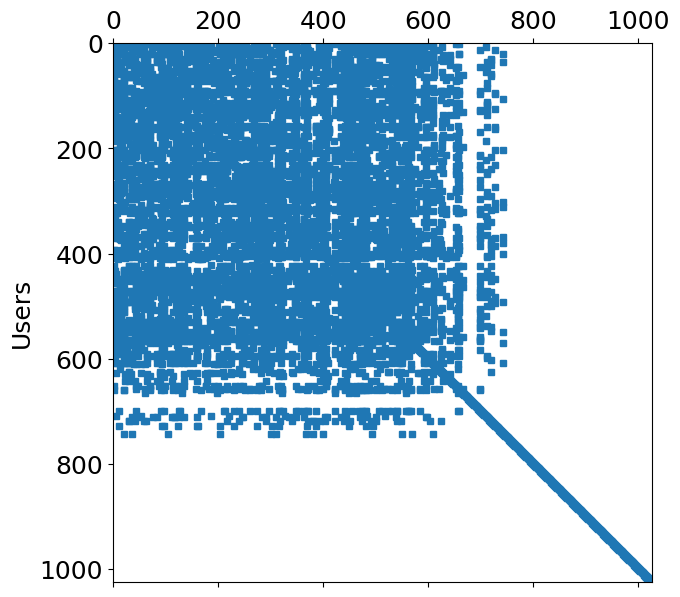

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1026 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.940000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.99e-03 nnz(S)/p=1.55e+01
* iter=1 time=6.31e-03 obj=1.73e+03 |delta(obj)|/obj=4.11e-01 nnz(X,L,W)/p=[1.55e+01 2.42e+01 1.00e+00] lns_iter=2 
* iter=2 time=2.08e-02 obj=1.73e+03 |delta(obj)|/obj=0.00e+00 nnz(X,L,W)/p=[1.55e+01 2.42e+01 3.21e+00] lns_iter=1 
#SQUIC Finished: time=3.31e-02 nnz(X,W)/p=[1.55e+0

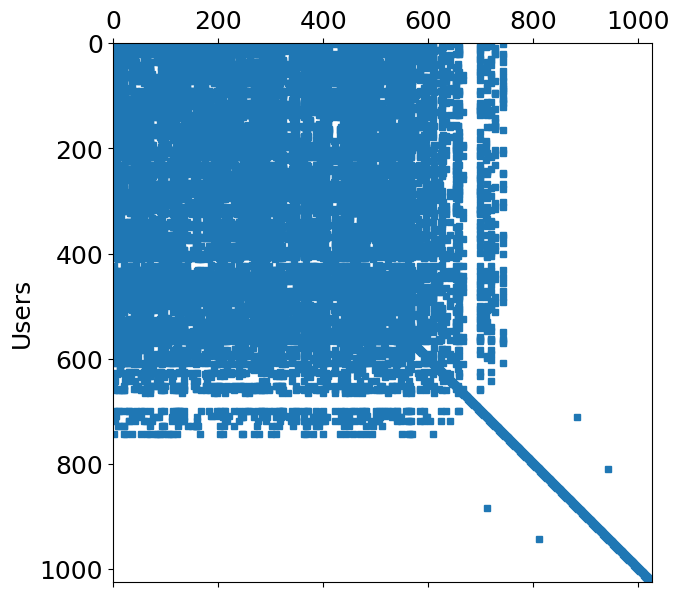

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1026 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.930000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.95e-03 nnz(S)/p=2.23e+01
* iter=1 time=5.87e-03 obj=1.73e+03 |delta(obj)|/obj=4.11e-01 nnz(X,L,W)/p=[2.23e+01 2.92e+01 1.00e+00] lns_iter=2 
* iter=2 time=1.02e-02 obj=1.73e+03 |delta(obj)|/obj=0.00e+00 nnz(X,L,W)/p=[2.23e+01 2.92e+01 8.17e+00] lns_iter=1 
#SQUIC Finished: time=2.12e-02 nnz(X,W)/p=[2.23e+0

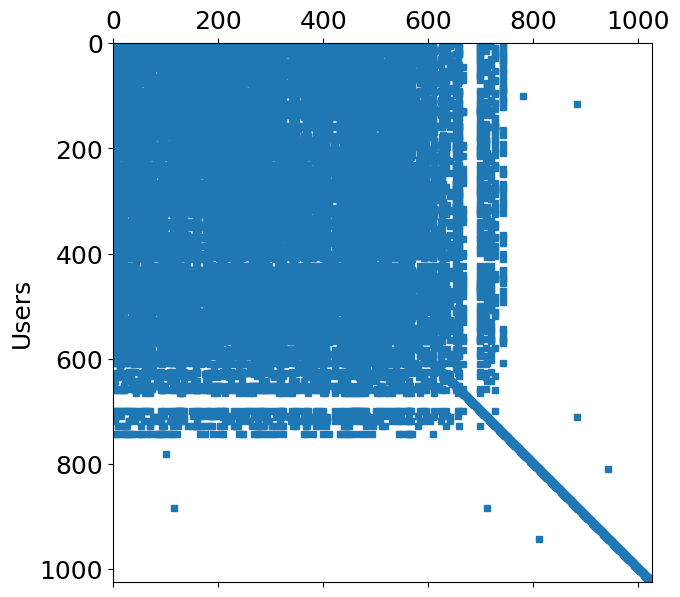

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1026 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.920000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.74e-03 nnz(S)/p=2.93e+01
* iter=1 time=6.13e-03 obj=1.73e+03 |delta(obj)|/obj=4.11e-01 nnz(X,L,W)/p=[2.93e+01 3.35e+01 1.00e+00] lns_iter=2 
* iter=2 time=1.16e-02 obj=1.73e+03 |delta(obj)|/obj=0.00e+00 nnz(X,L,W)/p=[2.93e+01 3.35e+01 1.71e+01] lns_iter=1 
#SQUIC Finished: time=2.43e-02 nnz(X,W)/p=[2.93e+0

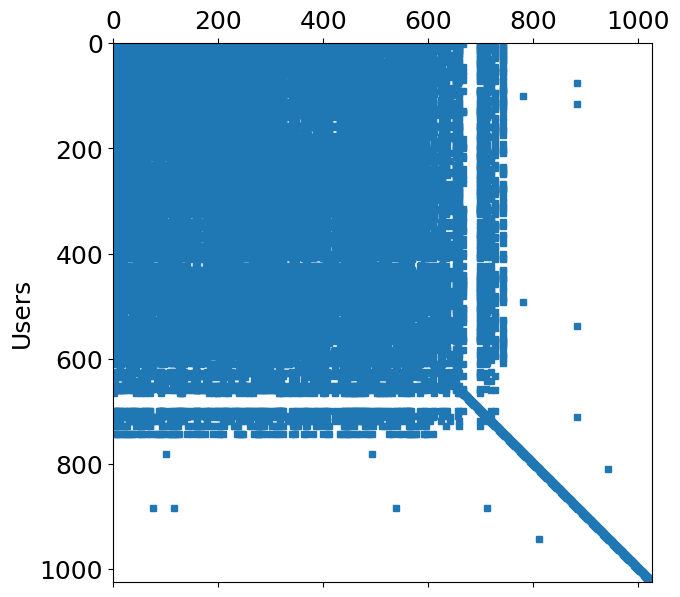

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1026 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.900000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.75e-03 nnz(S)/p=4.21e+01
* iter=1 time=7.96e-03 obj=1.73e+03 |delta(obj)|/obj=4.10e-01 nnz(X,L,W)/p=[4.21e+01 3.89e+01 1.00e+00] lns_iter=2 
* iter=2 time=1.89e-02 obj=1.73e+03 |delta(obj)|/obj=0.00e+00 nnz(X,L,W)/p=[4.21e+01 3.89e+01 6.75e+01] lns_iter=1 
#SQUIC Finished: time=3.64e-02 nnz(X,W)/p=[4.21e+0

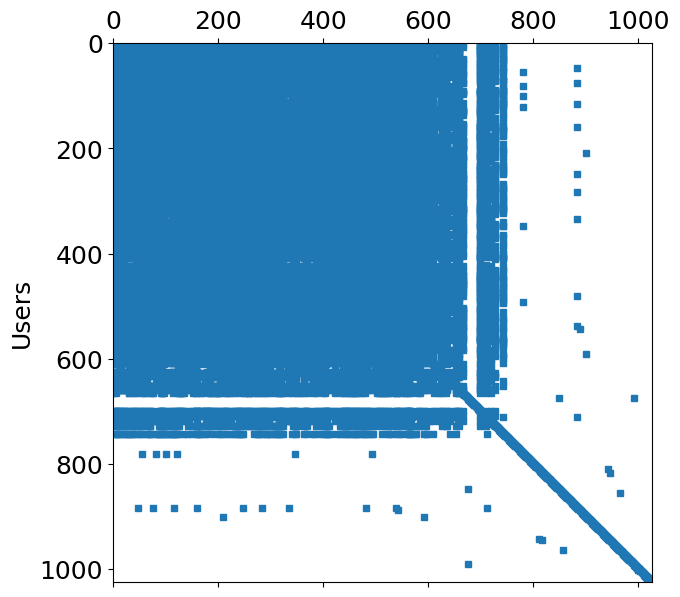

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1026 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.500000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=7.03e-03 nnz(S)/p=1.23e+02
* iter=1 time=4.62e-02 obj=1.93e+03 |delta(obj)|/obj=4.72e-01 nnz(X,L,W)/p=[1.23e+02 8.69e+01 1.00e+00] lns_iter=5 
* iter=2 time=8.56e-02 obj=1.92e+03 |delta(obj)|/obj=5.94e-03 nnz(X,L,W)/p=[1.23e+02 8.69e+01 1.18e+02] lns_iter=7 
* iter=3 time=2.85e+00 obj=1.70e+03 |delta(obj)|/o

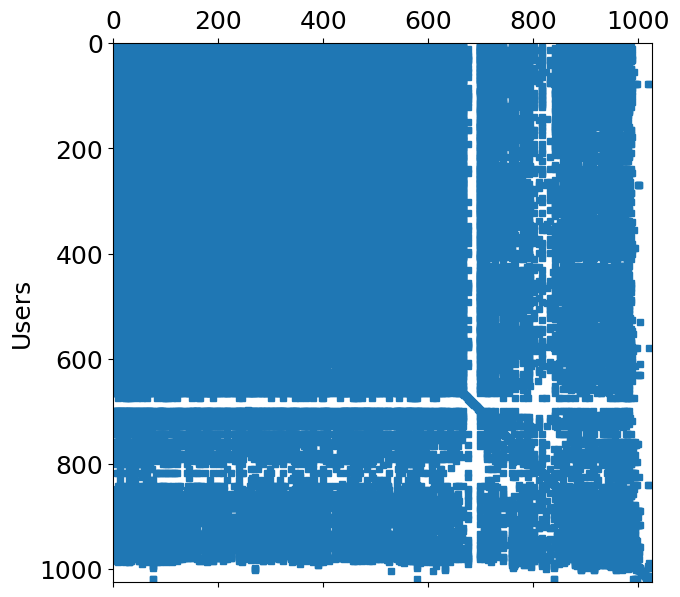

In [38]:
squic_norm_dict = {}

data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    X, _, computation_time = compute_squic(Y_new, rho)
    computation_time = round(computation_time, 2)
    squic_norm_dict[rho] = X
    print(f"time required: {computation_time} seconds")

    nonz, nonz_r = count_nnz(squic_norm_dict[rho], ROWS)

    if is_symmetric(squic_norm_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sym.append('Yes')
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sym.append('No')

    data_nnz.append(nonz)
    data_nnzr.append(round(nonz_r, 2))
    data_time.append(computation_time)

    if nonz == ROWS:
        print(f"For rho = {rho} just element on the diagonal")
        sparsity_pattern(squic_norm_dict[rho])
    elif nonz == ROWS * ROWS:
        print(f"For rho = {rho} big dense matrix")
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        # sparsity_pattern(rho_dict[rho])
    else:
        print(f"For rho = {rho} there are some nnz")
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        sparsity_pattern(squic_norm_dict[rho])


table_squic_norm = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]

# SQUIC-Fit

In [115]:
fit_norm_dict = {}

In [116]:
Y = df.T.to_numpy()  # Convert to (users, days)

# normalize the Y input data to achieve unit variance
Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
# normalizes each row so that the std dev of each user's balance over the days becomes 1

# Y_new has shape (Users × Days).
# S will have shape (Users × Users).

# double check if this is correct by 
S = np.cov(Y_new, bias=True) # "bias=true" you force cove to use n samples instead of n-1

/var/folders/s6/4jprwbqj4012tkll2ww6r5hr0000gq/T/ipykernel_12981/1629358900.py:4: RuntimeWarning: divide by zero encountered in divide
  Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation


In [117]:
stds = np.std(Y, axis=1)
safe_stds = np.clip(stds, 1e-8, None)  # don't allow std < 1e-8
Y_new = np.diag(1 / safe_stds) @ Y

In [121]:
l = [9e-1, 5e-1, 2e-1, 1e-1, 9e-2, 5e-2, 2e-2, 1e-2, 1e-3]

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=6.45e-04 nnz(S)/p=7.07e+00
* iter=1 time=1.24e-03 obj=1.91e+02 |delta(obj)|/obj=4.23e-01 nnz(X,L,W)/p=[7.07e+00 5.07e+00 1.00e+00] lns_iter=3 
* iter=2 time=2.42e-03 obj=1.86e+02 |delta(obj)|/obj=2.68e-02 nnz(X,L,W)/p=[7.07e+00 5.07e+00 8.84e+00] lns_iter=3 
* iter=3 time=2.25e-03 obj=1.82e+02 |delta(obj)|/ob

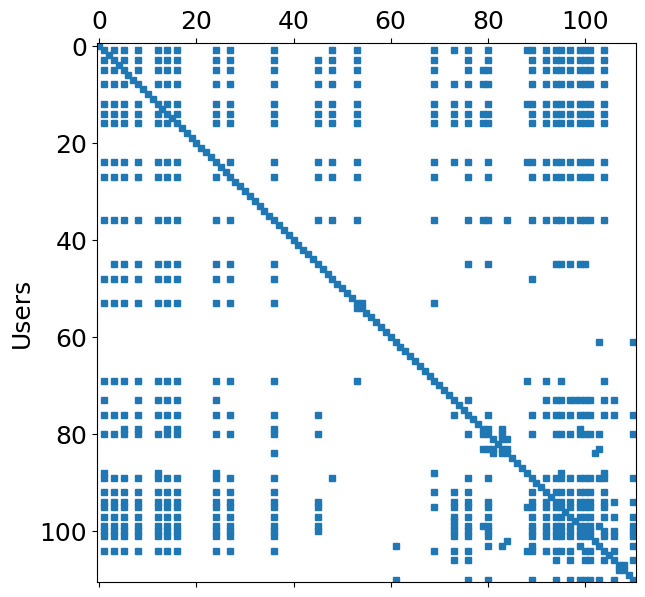

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=7.55e-04 nnz(S)/p=3.98e+01
* iter=1 time=5.59e-03 obj=1.55e+02 |delta(obj)|/obj=2.93e-01 nnz(X,L,W)/p=[3.98e+01 3.40e+01 1.00e+00] lns_iter=6 
* iter=2 time=2.94e-03 obj=1.51e+02 |delta(obj)|/obj=2.87e-02 nnz(X,L,W)/p=[3.98e+01 3.40e+01 4.14e+01] lns_iter=7 
* iter=3 time=8.50e-03 obj=1.44e+02 |delta(obj)|/ob

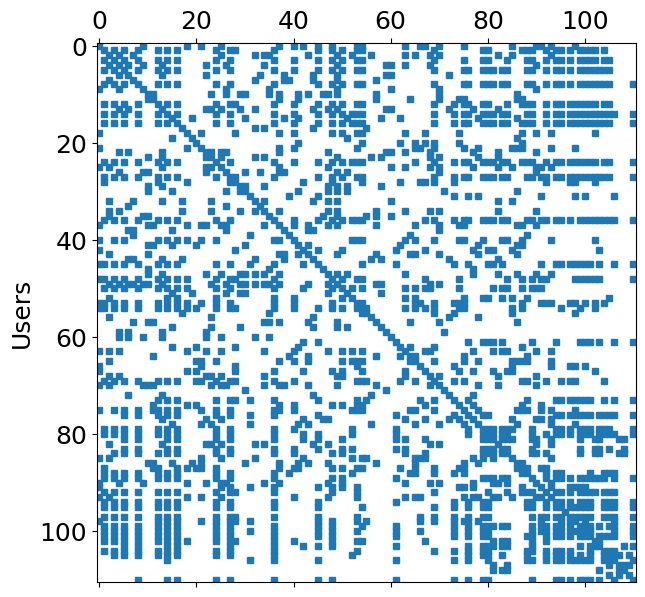

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      2.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.34e-04 nnz(S)/p=7.79e+01
* iter=1 time=2.66e-03 obj=1.11e+02 |delta(obj)|/obj=7.31e-03 nnz(X,L,W)/p=[7.79e+01 5.29e+01 1.00e+00] lns_iter=7 
* iter=2 time=4.77e-03 obj=1.01e+02 |delta(obj)|/obj=9.89e-02 nnz(X,L,W)/p=[7.79e+01 5.29e+01 1.09e+02] lns_iter=8 
* iter=3 time=2.70e-02 obj=9.18e+01 |delta(obj)|/ob

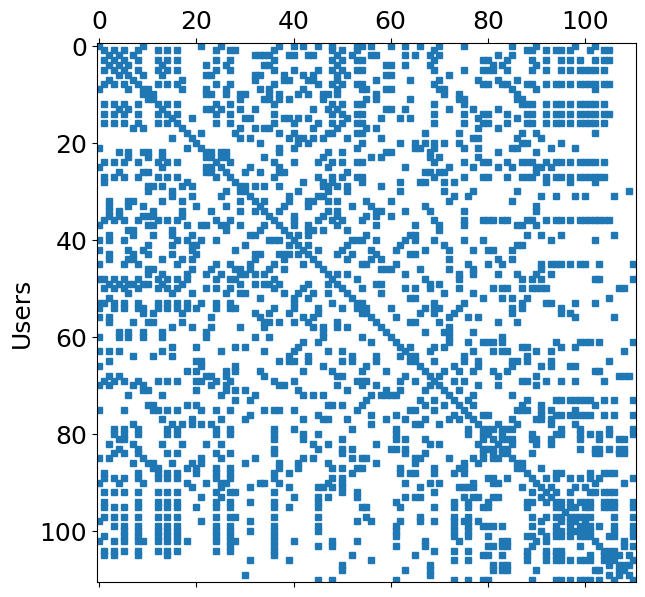

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.61e-04 nnz(S)/p=9.29e+01
* iter=1 time=2.66e-03 obj=8.96e+01 |delta(obj)|/obj=2.28e-01 nnz(X,L,W)/p=[9.29e+01 5.45e+01 1.00e+00] lns_iter=7 
* iter=2 time=1.47e-02 obj=7.59e+01 |delta(obj)|/obj=1.81e-01 nnz(X,L,W)/p=[9.29e+01 5.45e+01 1.07e+02] lns_iter=8 
* iter=3 time=4.51e-02 obj=6.69e+01 |delta(obj)|/ob

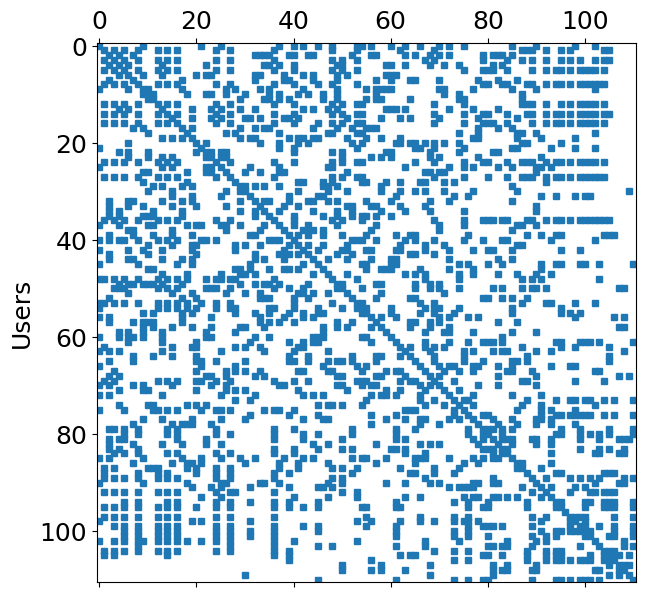

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.83e-04 nnz(S)/p=9.43e+01
* iter=1 time=2.80e-03 obj=8.73e+01 |delta(obj)|/obj=2.60e-01 nnz(X,L,W)/p=[9.43e+01 5.45e+01 1.00e+00] lns_iter=7 
* iter=2 time=4.90e-03 obj=7.34e+01 |delta(obj)|/obj=1.90e-01 nnz(X,L,W)/p=[9.43e+01 5.45e+01 1.08e+02] lns_iter=8 
* iter=3 time=3.94e-02 obj=6.41e+01 |delta(obj)|/ob

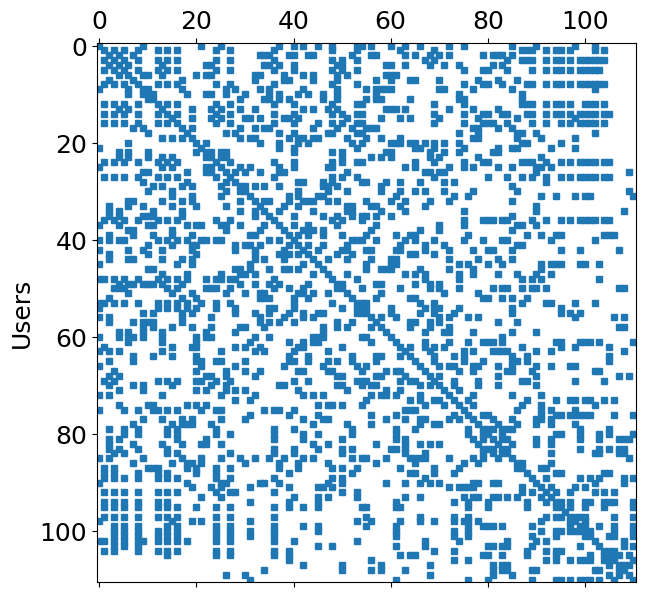

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.48e-04 nnz(S)/p=1.01e+02
* iter=1 time=2.69e-03 obj=7.78e+01 |delta(obj)|/obj=4.14e-01 nnz(X,L,W)/p=[1.01e+02 5.45e+01 1.00e+00] lns_iter=7 
* iter=2 time=5.32e-03 obj=6.93e+01 |delta(obj)|/obj=1.22e-01 nnz(X,L,W)/p=[1.01e+02 5.45e+01 1.01e+02] lns_iter=9 
* iter=3 time=3.86e-02 obj=5.44e+01 |delta(obj)|/ob

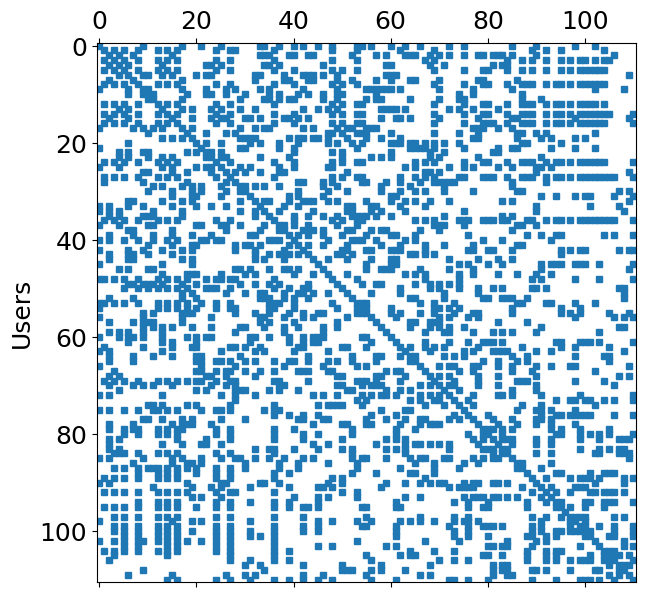

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      2.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.89e-04 nnz(S)/p=1.06e+02
* iter=1 time=2.76e-03 obj=7.04e+01 |delta(obj)|/obj=5.63e-01 nnz(X,L,W)/p=[1.06e+02 5.45e+01 1.00e+00] lns_iter=7 
* iter=2 time=5.25e-03 obj=6.12e+01 |delta(obj)|/obj=1.49e-01 nnz(X,L,W)/p=[1.06e+02 5.45e+01 1.01e+02] lns_iter=9 
* iter=3 time=5.86e-02 obj=4.49e+01 |delta(obj)|/ob

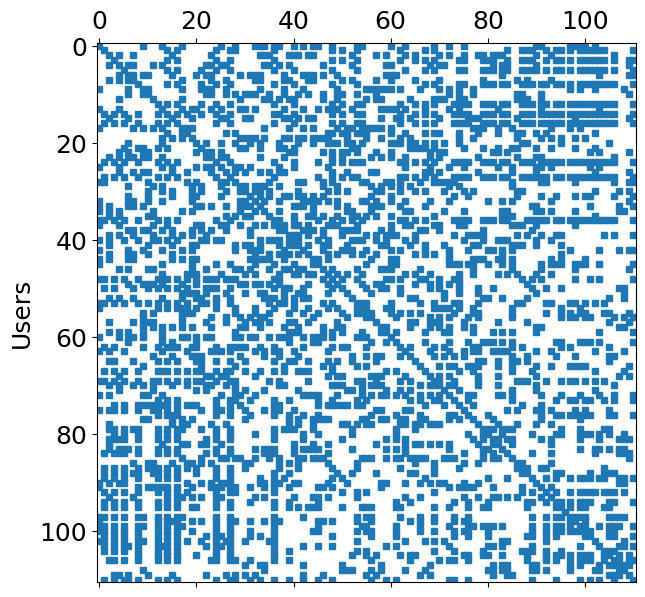

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=6.44e-04 nnz(S)/p=1.07e+02
* iter=1 time=2.65e-03 obj=6.78e+01 |delta(obj)|/obj=6.22e-01 nnz(X,L,W)/p=[1.07e+02 5.45e+01 1.00e+00] lns_iter=7 
* iter=2 time=5.46e-03 obj=5.85e+01 |delta(obj)|/obj=1.60e-01 nnz(X,L,W)/p=[1.07e+02 5.45e+01 1.02e+02] lns_iter=9 
* iter=3 time=4.35e-02 obj=4.15e+01 |delta(obj)|/ob

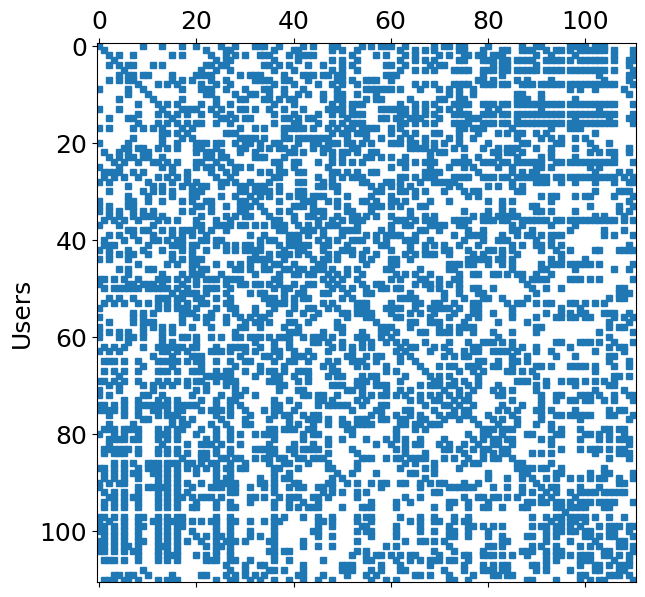

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-03 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.79e-04 nnz(S)/p=1.09e+02
* iter=1 time=2.62e-03 obj=6.55e+01 |delta(obj)|/obj=6.80e-01 nnz(X,L,W)/p=[1.09e+02 5.45e+01 1.00e+00] lns_iter=7 
* iter=2 time=5.53e-03 obj=5.60e+01 |delta(obj)|/obj=1.69e-01 nnz(X,L,W)/p=[1.09e+02 5.45e+01 1.02e+02] lns_iter=9 
* iter=3 time=4.31e-02 obj=3.86e+01 |delta(obj)|/ob

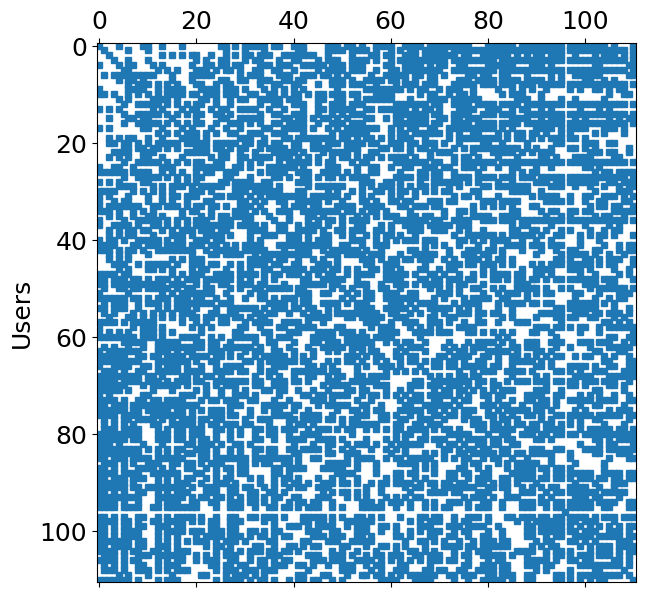

In [122]:
data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    fit_norm_dict[rho], end_time = squic_fit(Y_new, lambda_val=rho, eta=rho * 0.1)
    end_time = round(end_time, 2)
    print(f"required time: {end_time}")
    
    nnz, nnz_r = nnz_fit(fit_norm_dict[rho], ROWS)
    print(f"nnz = {nnz} per rows = {nnz_r}")

    if is_symmetric(fit_norm_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sym.append('Yes')
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sym.append('No')

    sparsity_pattern(fit_norm_dict[rho])

    data_nnz.append(nnz)
    data_nnzr.append(round(nnz_r, 2))
    data_time.append(end_time)

table_fit = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]

# Table

In [123]:
def table(data, title, l):
    table = tabulate(
        data,
        headers=[title] + l,
        tablefmt="fancy_grid",
        numalign="center",
        stralign="center"
    )
    return table

In [124]:
print(table(table_squic_norm, "SQUIC NORM", l))

print(table(table_fit, "SQUIC FIT NORM", l))

╒══════════════╤═══════╤═══════╤═══════╤═══════╤════════╤════════╤════════╤════════╤═════════╕
│  SQUIC NORM  │  0.9  │  0.5  │  0.2  │  0.1  │  0.09  │  0.05  │  0.02  │  0.01  │  0.001  │
╞══════════════╪═══════╪═══════╪═══════╪═══════╪════════╪════════╪════════╪════════╪═════════╡
│     NNZ      │ 10627 │ 5885  │ 4775  │ 3461  │  2991  │  2889  │  2633  │  2339  │   749   │
├──────────────┼───────┼───────┼───────┼───────┼────────┼────────┼────────┼────────┼─────────┤
│   NNZ/Row    │ 95.74 │ 53.02 │ 43.02 │ 31.18 │ 26.95  │ 26.03  │ 23.72  │ 21.07  │  6.75   │
├──────────────┼───────┼───────┼───────┼───────┼────────┼────────┼────────┼────────┼─────────┤
│   Time (s)   │ 35.33 │ 7.75  │ 3.44  │ 1.59  │  1.49  │  0.87  │  0.25  │  0.04  │  0.01   │
├──────────────┼───────┼───────┼───────┼───────┼────────┼────────┼────────┼────────┼─────────┤
│  Symmetric   │  Yes  │  Yes  │  Yes  │  Yes  │  Yes   │  Yes   │  Yes   │  Yes   │   Yes   │
╘══════════════╧═══════╧═══════╧═══════╧═══════╧══